# Phase 3 (partial) — Exploratory Data Analysis for Foodie India MP1

This notebook is the interactive version of `scripts/02_eda_partial.py`.

It uses the cleaned + imputed dataset (`data/restaurant_clean_final.csv`,
produced by `01_clean_data.ipynb`) to produce a first pass of summary
statistics and a handful of business-relevant charts. This is a **partial**
pass — enough to sanity-check the cleaned data and surface early patterns
before the full Phase 3/4 (visualization + hypothesis testing).

**Note on paths:** this notebook lives in `notebooks/`, so file paths are
written relative to the project root using `../`. Charts are both displayed
inline and saved to `../figures/`.

## 1. Imports

- `pandas` for loading and grouping the cleaned data.
- `matplotlib.pyplot` for all charts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Paths and category orderings

`DAY_ORDER` / `TIME_ORDER` fix the display order of categories on charts —
without this, `pandas`/`matplotlib` would use alphabetical or
first-seen order, which isn't how a reader expects a week or a day to be laid out.

In [2]:
IN_PATH = "../data/restaurant_clean_final.csv"
FIG_DIR = "../figures"

DAY_ORDER = ["Thur", "Fri", "Sat", "Sun"]
TIME_ORDER = ["Lunch", "Dinner"]

## 3. Chart styling

Colors are fixed, categorical, and colorblind-safe (the Okabe-Ito palette),
and are assigned **by entity identity** — e.g. `BLUE` always means the same
thing across charts — rather than re-cycled per chart, so a reader can build
a consistent mental map of what each color means.

`plt.rcParams.update(...)` applies a clean, minimal style (white background,
light gridlines, no top/right border) globally so every chart below looks
consistent without repeating style code in every function.

In [3]:
BLUE = "#0072B2"
ORANGE = "#E69F00"
GREEN = "#009E73"
VERMILLION = "#D55E00"
GRAY = "#666666"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#999999",
    "axes.grid": True,
    "grid.color": "#e6e6e6",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

## 4. Load the cleaned data

In [4]:
df = pd.read_csv(IN_PATH)
df.head()

,Amount,Tip,Gender,Smoker,Day,Time,Partysize,TipPct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


## 5. Summary statistics

`describe()` on the numeric columns gives count/mean/std/quartiles in one
shot — this is the first sanity check that imputation didn't introduce
impossible values (e.g. negative amounts, party sizes outside 1–6).

The category counts for `Gender`, `Smoker`, `Day`, and `Time` confirm every
row now has a valid, non-missing label in these columns.

In [5]:
print("=== Summary statistics ===")
print(df[["Amount", "Tip", "TipPct", "Partysize"]].describe().round(2))

print("\n=== Category counts ===")
for col in ["Gender", "Smoker", "Day", "Time"]:
    print(f"\n{col}:")
    print(df[col].value_counts())

=== Summary statistics ===
       Amount     Tip  TipPct  Partysize
count  365.00  365.00  365.00     365.00
mean    21.21    3.08   16.16       2.56
std     10.91    2.04   13.10       0.88
min      1.01    0.01    0.15       1.00
25%     14.31    2.00   11.15       2.00
50%     19.10    2.87   14.67       2.00
75%     25.68    3.50   17.97       3.00
max    117.81   22.23  166.34       6.00

=== Category counts ===

Gender:
Gender
Male      209
Female    156
Name: count, dtype: int64

Smoker:
Smoker
No     220
Yes    145
Name: count, dtype: int64

Day:
Day
Sat     122
Sun     108
Thur     96
Fri      39
Name: count, dtype: int64

Time:
Time
Dinner    228
Lunch     137
Name: count, dtype: int64


## 6. Chart 1 — Distribution of Bill Amount and Tip %

Two histograms side by side: the raw bill amount, and tip as a percentage
of the bill. Looking at `TipPct` rather than raw `Tip` here removes the
effect of bill size, so we're looking at tipping *behavior* rather than
just which parties spent more.

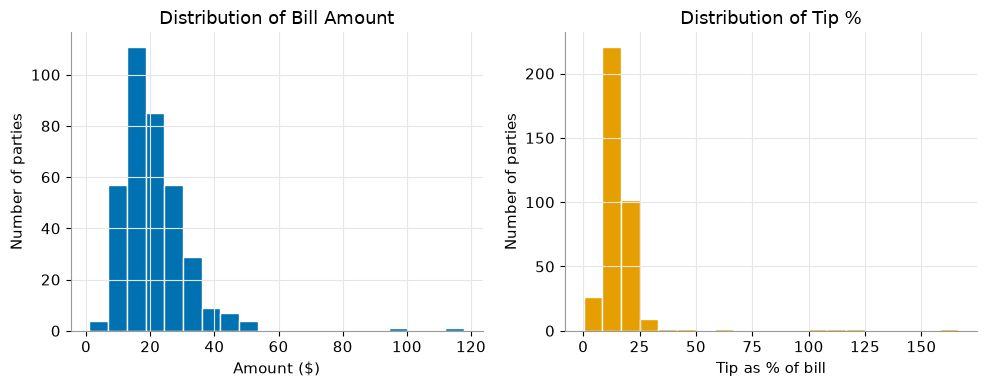

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df["Amount"], bins=20, color=BLUE, edgecolor="white")
axes[0].set_title("Distribution of Bill Amount")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Number of parties")

axes[1].hist(df["TipPct"], bins=20, color=ORANGE, edgecolor="white")
axes[1].set_title("Distribution of Tip %")
axes[1].set_xlabel("Tip as % of bill")
axes[1].set_ylabel("Number of parties")

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/01_amount_tippct_distribution.png", dpi=150)
plt.show()

## 7. Chart 2 — Average Tip % by Day and by Time

Bar charts of mean `TipPct` grouped by `Day` and by `Time`, in the fixed
orderings defined earlier (`reindex(DAY_ORDER)` / `reindex(TIME_ORDER)`).
The value is annotated above each bar so exact figures don't need to be
read off the axis.

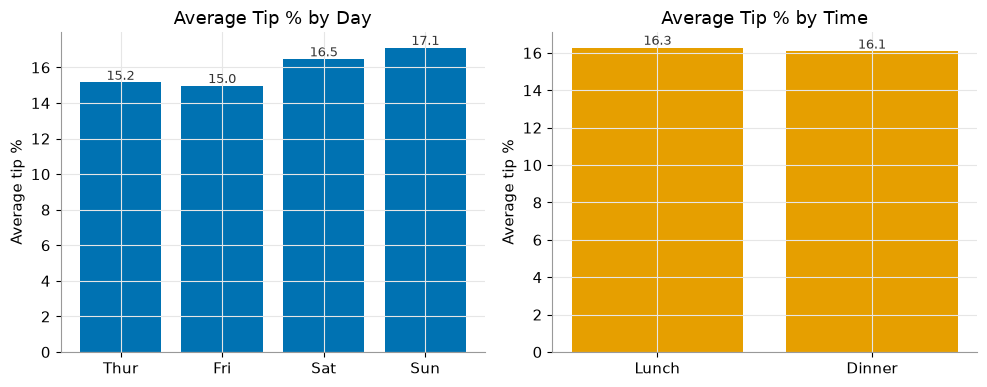

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

by_day = df.groupby("Day")["TipPct"].mean().reindex(DAY_ORDER)
axes[0].bar(by_day.index, by_day.values, color=BLUE)
axes[0].set_title("Average Tip % by Day")
axes[0].set_ylabel("Average tip %")
for i, v in enumerate(by_day.values):
    axes[0].text(i, v + 0.15, f"{v:.1f}", ha="center", fontsize=9, color="#333")

by_time = df.groupby("Time")["TipPct"].mean().reindex(TIME_ORDER)
axes[1].bar(by_time.index, by_time.values, color=ORANGE)
axes[1].set_title("Average Tip % by Time")
axes[1].set_ylabel("Average tip %")
for i, v in enumerate(by_time.values):
    axes[1].text(i, v + 0.15, f"{v:.1f}", ha="center", fontsize=9, color="#333")

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/02_tippct_by_day_time.png", dpi=150)
plt.show()

## 8. Chart 3 — Tip % by Smoker Status

A box plot compares the full distribution (not just the mean) of `TipPct`
between smoking and non-smoking parties, which reveals spread and outliers
that a bar chart of averages would hide.

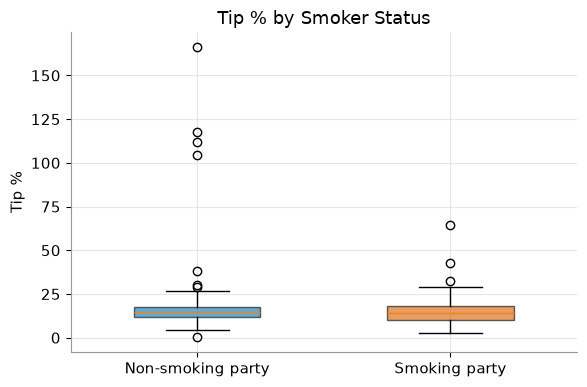

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
groups = [df.loc[df["Smoker"] == cat, "TipPct"].dropna() for cat in ["No", "Yes"]]
bp = ax.boxplot(groups, tick_labels=["Non-smoking party", "Smoking party"],
                 patch_artist=True, widths=0.5)
for patch, color in zip(bp["boxes"], [BLUE, VERMILLION]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title("Tip % by Smoker Status")
ax.set_ylabel("Tip %")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/03_tippct_by_smoker.png", dpi=150)
plt.show()

## 9. Chart 4 — Party Volume by Day and Time

A grouped bar chart of how many parties dined at each `Day`/`Time`
combination. This checks whether the earlier Tip %-by-day patterns might
just be an artifact of some slots having very few observations (small
sample sizes make averages noisy).

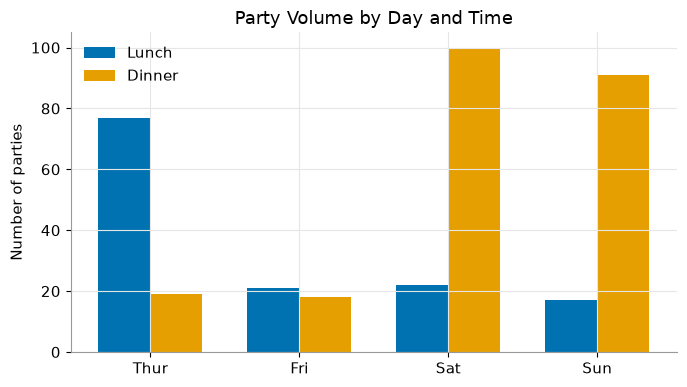

Saved 4 charts to ../figures/


In [9]:
counts = df.groupby(["Day", "Time"]).size().unstack("Time").reindex(DAY_ORDER)
counts = counts[TIME_ORDER]

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(counts.index))
width = 0.35
ax.bar([i - width / 2 for i in x], counts["Lunch"], width, label="Lunch", color=BLUE)
ax.bar([i + width / 2 for i in x], counts["Dinner"], width, label="Dinner", color=ORANGE)
ax.set_xticks(list(x))
ax.set_xticklabels(counts.index)
ax.set_ylabel("Number of parties")
ax.set_title("Party Volume by Day and Time")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/04_party_volume_day_time.png", dpi=150)
plt.show()

print(f"Saved 4 charts to {FIG_DIR}/")

## 10. Chart 5 — Tip % by Waiter Gender

Box plot comparing the full `TipPct` distribution between male and female
waiters. This was deferred from the first EDA pass — worth checking
whether tipping behavior differs by waiter gender before it's raised (or
ruled out) as a staffing consideration.

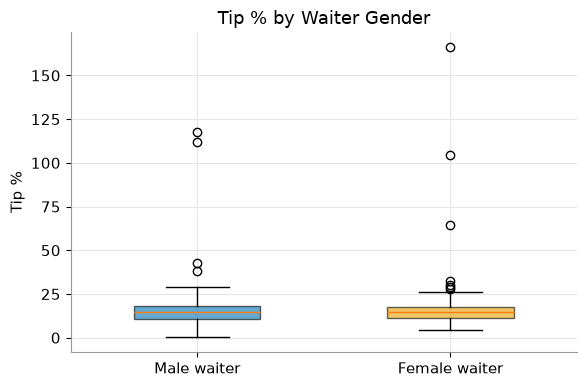

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
groups = [df.loc[df["Gender"] == cat, "TipPct"].dropna() for cat in ["Male", "Female"]]
bp = ax.boxplot(groups, tick_labels=["Male waiter", "Female waiter"],
                 patch_artist=True, widths=0.5)
for patch, color in zip(bp["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title("Tip % by Waiter Gender")
ax.set_ylabel("Tip %")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/05_tippct_by_gender.png", dpi=150)
plt.show()

**Reading it:** medians and interquartile ranges are nearly identical
between male and female waiters — the only visible difference is a handful
of high outliers on the female side (including the same very-small-bill
166% outlier flagged in Chart 1). No evidence here that waiter gender
drives tipping behavior.

## 11. Chart 6 — Average Tip % by Party Size

Deferred from the first pass. Bar chart of mean `TipPct` per party size,
annotated with the sample count (`n=`) behind each bar — this matters
because some party sizes are rare, and an average over a handful of rows
is much noisier than one over hundreds.

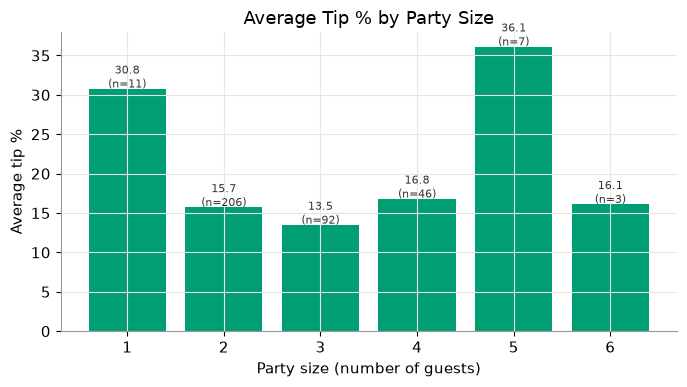

In [11]:
by_size = df.groupby("Partysize")["TipPct"].mean().sort_index()
counts = df.groupby("Partysize").size().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_size.index, by_size.values, color=GREEN)
ax.set_title("Average Tip % by Party Size")
ax.set_xlabel("Party size (number of guests)")
ax.set_ylabel("Average tip %")
ax.set_xticks(list(by_size.index))
for size, v in by_size.items():
    n = counts.loc[size]
    ax.text(size, v + 0.15, f"{v:.1f}\n(n={n})", ha="center", fontsize=8, color="#333")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/06_tippct_by_partysize.png", dpi=150)
plt.show()

**Reading it:** parties of 2–4 (the bulk of the data, n=92–206) tip a
fairly stable 13–17%. Sizes 1, 5, and 6 look like outliers (30.8%, 36.1%,
16.1%) but each rests on **n ≤ 11** — too few observations to treat as a
real effect rather than noise from one or two generous tippers. Any
recommendation involving party size should lean on the 2–4 range only, or
flag the small-n groups explicitly rather than presenting them as
established patterns.

## 12. Chart 7 — Average Bill Amount by Day and Time

A revenue-side view to pair with Chart 4's volume view: does spending per
visit differ by day/time slot the way traffic does? Relevant for staffing
and marketing-timing recommendations, distinct from the tipping-behavior
question the earlier charts address.

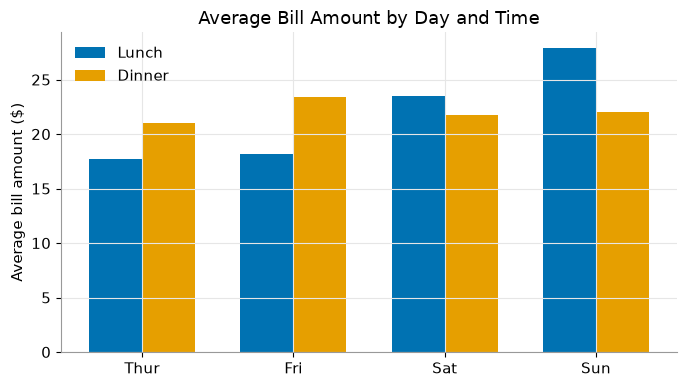

In [12]:
avg = df.groupby(["Day", "Time"])["Amount"].mean().unstack("Time").reindex(DAY_ORDER)
avg = avg[TIME_ORDER]

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(avg.index))
width = 0.35
ax.bar([i - width / 2 for i in x], avg["Lunch"], width, label="Lunch", color=BLUE)
ax.bar([i + width / 2 for i in x], avg["Dinner"], width, label="Dinner", color=ORANGE)
ax.set_xticks(list(x))
ax.set_xticklabels(avg.index)
ax.set_ylabel("Average bill amount ($)")
ax.set_title("Average Bill Amount by Day and Time")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/07_amount_by_day_time.png", dpi=150)
plt.show()

**Reading it:** weekday (Thur/Fri) dinners bring in more per bill than
weekday lunches, but the pattern **flips on the weekend** — Saturday and
Sunday lunches average higher bills than weekend dinners, with Sunday
lunch the highest of any slot (~$28). Combined with Chart 4 (Thursday is
lunch-heavy in volume, Sat/Sun are dinner-heavy in volume), this suggests
weekend lunch is a comparatively under-served but high-value slot worth
a closer look for the recommendations section — though note Sat/Sun lunch
also has the smallest sample sizes of the four dinner/lunch combinations,
so this should be framed as a lead to investigate, not a settled fact.